In [44]:
import geopandas as gpd
import matplotlib.pyplot as plt
import math

In [45]:
import geopandas as gpd

# URL to the zipped shapefile
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

# Read the shapefile directly from the URL
world = gpd.read_file(url)

In [46]:
world_modified = world.copy()

In [47]:
world_modified.head(3)

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."


In [48]:
areas = [g.area for g in world_modified.geometry.to_list()]
areas_logs = [math.log(a) for a in areas]

In [49]:
world_modified['geometry'] = [g.centroid.buffer(areas_logs[idx]) for idx, g in enumerate(world_modified.geometry.to_list())]

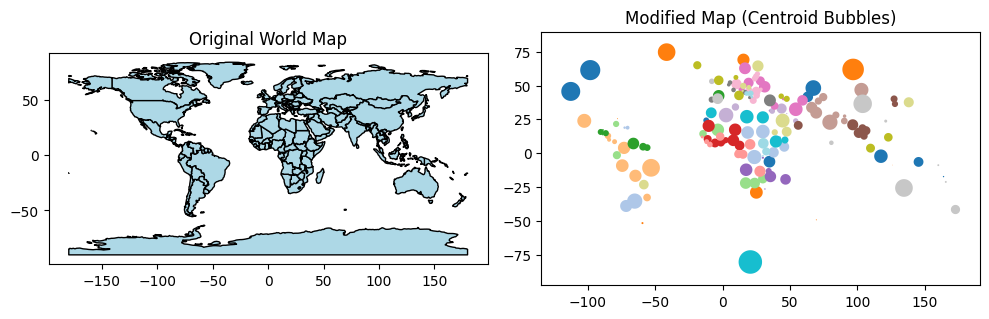

In [53]:
import matplotlib.pyplot as plt


f, ax = plt.subplots(1,2,figsize=(10,8))
world.plot(ax=ax[0], color='lightblue', edgecolor='black')
ax[0].set_title('Original World Map')

world_modified.plot(ax=ax[1], cmap='tab20')
ax[1].set_title('Modified Map (Centroid Bubbles)')

plt.tight_layout()
plt.show()